### Softmax_Classification
###### 여러 클래스 중 각 클래스일 확률을 계산해 주는 활성화 함수

In [2]:
import torch
import torch.nn.functional as F

z = torch.FloatTensor([1, 2, 3])
hypothesis = F.softmax(z, dim = 0)
print(hypothesis)

hypothesis.sum()

tensor([0.0900, 0.2447, 0.6652])


tensor(1.)

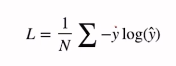

#### Cross Entropy Loss(Low - level)

In [15]:
import torch
import torch.nn.functional as F

z = torch.rand(3, 5, requires_grad = True)
hypothesis = F.softmax(z, dim = 1)
y = torch.randint(5, (3, )).long() # randint(min, max, size)
print(y)

y_one_hot = torch.zeros_like(hypothesis)
y_one_hot.scatter_(1, y.unsqueeze(1), 1) # scatter_(dim, index, value) dim: 어느 방향으로 값을 넣을지, index: 넣을 위치
# 함수 뒤에 _가 붙음으로써 원본 Tensor를 직접 수정

cost = (y_one_hot * -torch.log(hypothesis)).sum(dim = 1).mean()
cost2 = F.cross_entropy(z,y) # high level로 위의 식이랑 똑같다.
print(cost)
print(cost2)


tensor([2, 1, 1])
tensor(1.7223, grad_fn=<MeanBackward0>)
tensor(1.7223, grad_fn=<NllLossBackward0>)


In [18]:
import torch
import torch.nn.functional as F
import torch.optim as optim

x_train = torch.FloatTensor([[1, 2, 1, 1],
                             [2, 1, 3, 2],
                             [3, 1, 3, 4],
                             [4, 1, 5, 5],
                             [1, 7, 5, 5],
                             [1, 2, 5, 6],
                             [1, 6, 6, 6],
                             [1, 7, 7, 7]])
y_train = torch.LongTensor([2, 2, 2, 1, 1, 1, 0, 0])

W = torch.zeros((4, 3), requires_grad = True)
b = torch.zeros(1, requires_grad = True)

optimizer = optim.SGD([W, b], lr = 0.1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):
    hypothesis = F.softmax(x_train.matmul(W) + b, dim = 1)
    y_one_hot = torch.zeros_like(hypothesis)
    y_one_hot.scatter_(1, y_train.unsqueeze(1), 1)
    cost = (y_one_hot * -torch.log(F.softmax(hypothesis, dim = 1))).sum(dim = 1).mean()


    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print('Epoch {:4d} / {} Cost: {:.6f}'.format(epoch, nb_epochs, cost.item()))





Epoch    0 / 1000 Cost: 1.098612
Epoch  100 / 1000 Cost: 0.901535
Epoch  200 / 1000 Cost: 0.839114
Epoch  300 / 1000 Cost: 0.807826
Epoch  400 / 1000 Cost: 0.788472
Epoch  500 / 1000 Cost: 0.774822
Epoch  600 / 1000 Cost: 0.764449
Epoch  700 / 1000 Cost: 0.756191
Epoch  800 / 1000 Cost: 0.749398
Epoch  900 / 1000 Cost: 0.743671
Epoch 1000 / 1000 Cost: 0.738749


In [21]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

class SoftmaxClassifierModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 3)

    def forward(self, x):
        return self.linear(x)


x_train = torch.FloatTensor([[1, 2, 1, 1],
                             [2, 1, 3, 2],
                             [3, 1, 3, 4],
                             [4, 1, 5, 5],
                             [1, 7, 5, 5],
                             [1, 2, 5, 6],
                             [1, 6, 6, 6],
                             [1, 7, 7, 7]])

y_train = torch.LongTensor([2, 2, 2, 1, 1, 1, 0, 0])

model = SoftmaxClassifierModel()
optimizer = optim.SGD(model.parameters(), lr = 0.1)
nb_epochs = 1000

for epoch in range(nb_epochs + 1):
    prediction = model(x_train)
    cost = F.cross_entropy(prediction, y_train)

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print('Epoch {:4d} / {} Cost: {: .6f}'.format(epoch, nb_epochs,cost.item()))



Epoch    0 / 1000 Cost:  2.496434
Epoch  100 / 1000 Cost:  0.722772
Epoch  200 / 1000 Cost:  0.640014
Epoch  300 / 1000 Cost:  0.581591
Epoch  400 / 1000 Cost:  0.530458
Epoch  500 / 1000 Cost:  0.482409
Epoch  600 / 1000 Cost:  0.435816
Epoch  700 / 1000 Cost:  0.389881
Epoch  800 / 1000 Cost:  0.344241
Epoch  900 / 1000 Cost:  0.299197
Epoch 1000 / 1000 Cost:  0.258540


#### 이진분류: Sigmoid, 다중분류: Softmax